Cell 1 — Imports

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (10,5)

Cell 2 — Load data

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/daily_orders.csv")

df.columns = df.columns.str.lower().str.strip()
df["date"] = pd.to_datetime(df["date"])

df.head()

,restaurant_id,date,total_orders,total_revenue,avg_discount,promotion_flag,cancellation_rate,avg_delivery_time
0,6317637,2024-07-01,13,6649.26,3.1,False,0.046,35.4
1,6317637,2024-07-02,15,7636.46,6.7,False,0.086,34.2
2,6317637,2024-07-03,14,5930.51,3.5,False,0.023,42.2
3,6317637,2024-07-04,14,6032.38,24.7,True,0.038,35.5
4,6317637,2024-07-05,20,12043.87,0.7,False,0.074,41.3


Cell 3 — Date preprocessing

In [57]:
df["date"] = pd.to_datetime(df["date"])

df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month
df["day_name"] = df["date"].dt.day_name()
df["year"] = df["date"].dt.year

df.head()

,restaurant_id,date,total_orders,total_revenue,avg_discount,promotion_flag,cancellation_rate,avg_delivery_time,day,month,day_name,year
0,6317637,2024-07-01,13,6649.26,3.1,False,0.046,35.4,1,7,Monday,2024
1,6317637,2024-07-02,15,7636.46,6.7,False,0.086,34.2,2,7,Tuesday,2024
2,6317637,2024-07-03,14,5930.51,3.5,False,0.023,42.2,3,7,Wednesday,2024
3,6317637,2024-07-04,14,6032.38,24.7,True,0.038,35.5,4,7,Thursday,2024
4,6317637,2024-07-05,20,12043.87,0.7,False,0.074,41.3,5,7,Friday,2024


Cell 4- Daily order trends

In [58]:
print(df.columns.tolist())

['restaurant_id', 'date', 'total_orders', 'total_revenue', 'avg_discount', 'promotion_flag', 'cancellation_rate', 'avg_delivery_time', 'day', 'month', 'day_name', 'year']


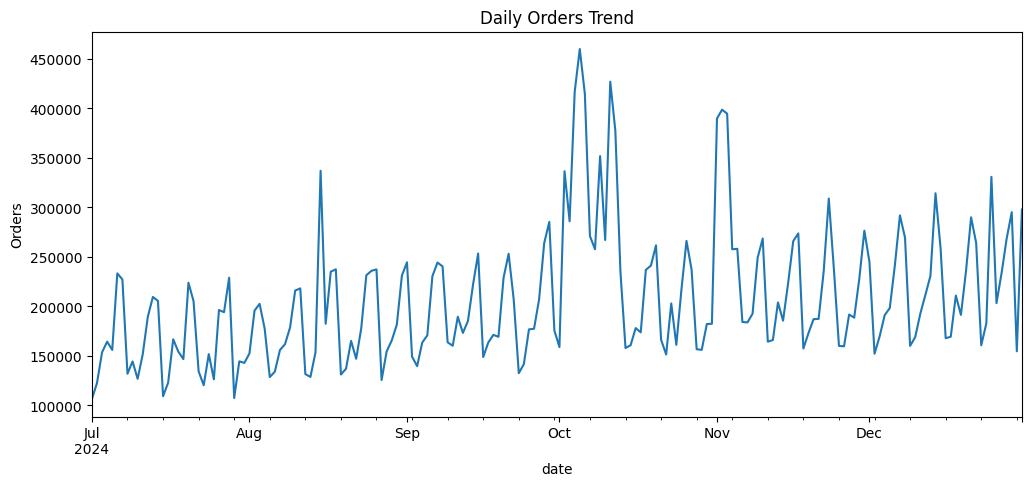

In [59]:
daily = df.groupby("date")["total_orders"].sum()

daily.plot(figsize=(12,5))
plt.title("Daily Orders Trend")
plt.ylabel("Orders")
plt.show()

Cell 5- Day-of-week patterns

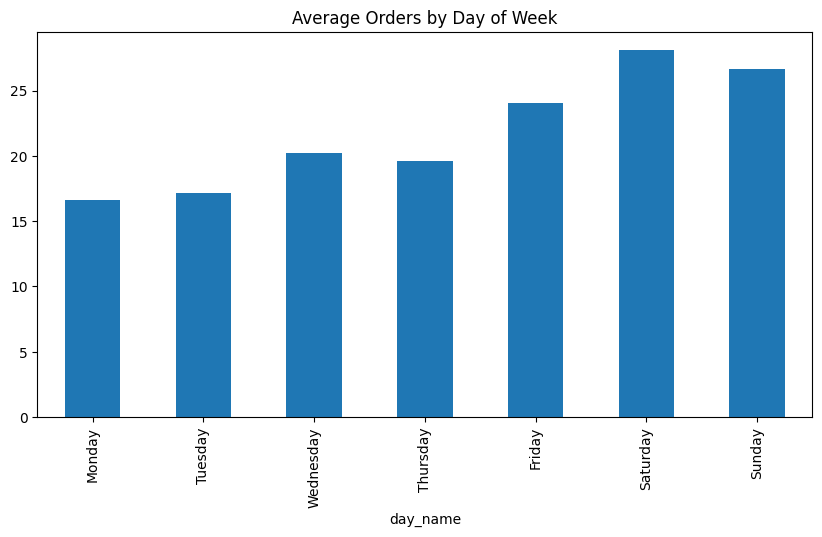

In [60]:
dow = df.groupby("day_name")["total_orders"].mean()

dow = dow.reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"])

dow.plot(kind="bar")
plt.title("Average Orders by Day of Week")
plt.show()

Cell 6- Weekend vs Weekday

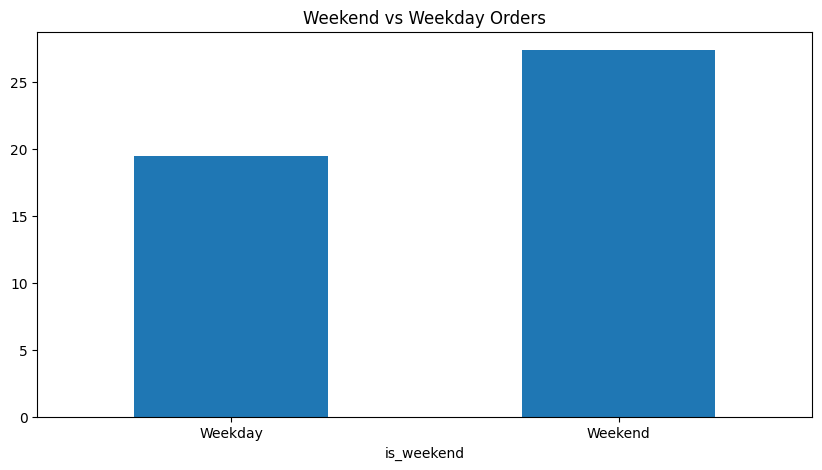

In [61]:
df["is_weekend"] = df["day_name"].isin(["Saturday","Sunday"])

weekend = df.groupby("is_weekend")["total_orders"].mean()

weekend.plot(kind="bar")
plt.xticks([0,1], ["Weekday","Weekend"], rotation=0)
plt.title("Weekend vs Weekday Orders")
plt.show()

Cell 7- Monthly seasonality

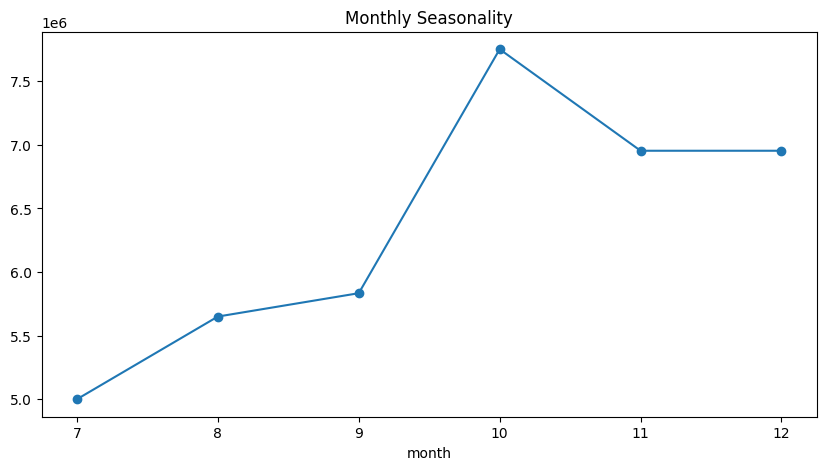

In [62]:
monthly = df.groupby("month")["total_orders"].sum()

monthly.plot(marker="o")
plt.title("Monthly Seasonality")
plt.show()

Cell 8- Revenue distribution

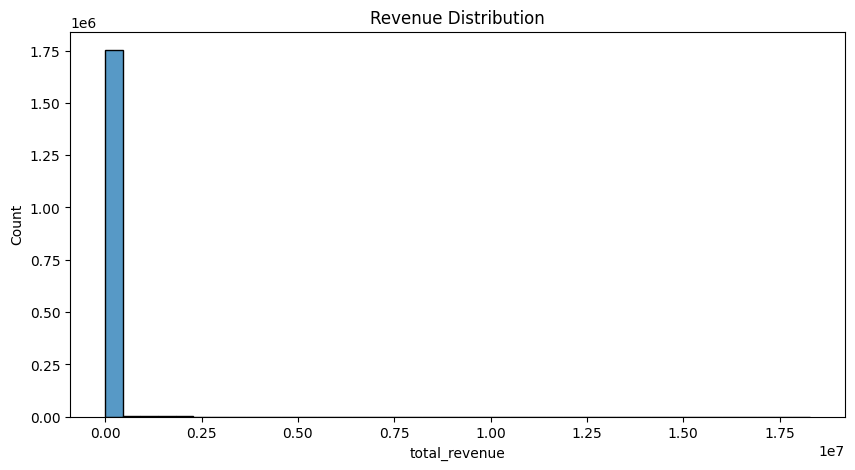

In [63]:
sns.histplot(df["total_revenue"], bins=40)
plt.title("Revenue Distribution")
plt.show()

Cell 9- Top/Bottom restaurants

In [64]:
rest_perf = df.groupby("restaurant_id")["total_orders"].sum()

print("Top 5 Restaurants")
print(rest_perf.sort_values(ascending=False).head())

print("\nBottom 5 Restaurants")
print(rest_perf.sort_values().head())

Top 5 Restaurants
restaurant_id
313368    16090
310143    16074
309844    14965
313093    14198
9166      14000
Name: total_orders, dtype: int64

Bottom 5 Restaurants
restaurant_id
18415386    642
18317479    652
18466422    655
18430587    656
18441707    658
Name: total_orders, dtype: int64
